# (Linear Gaussian) Square Root Filter

The notebook compares the square root filter with the normal kalman filter using linear measurement and dynamic models. The primary trade off is compared, namely that the square root filter exhibits superior numerical stability due to obtaining twice the numerical precision of the computed covariance at the expense of computational effort. This is particuarly noticable while using `Jax` , which uses 32-bit floating point values by default. 

# NOTE:

I think jax under the hood with scan does some lax magic that avoids numerical errors. Could be worth doing a naive scan comparison.



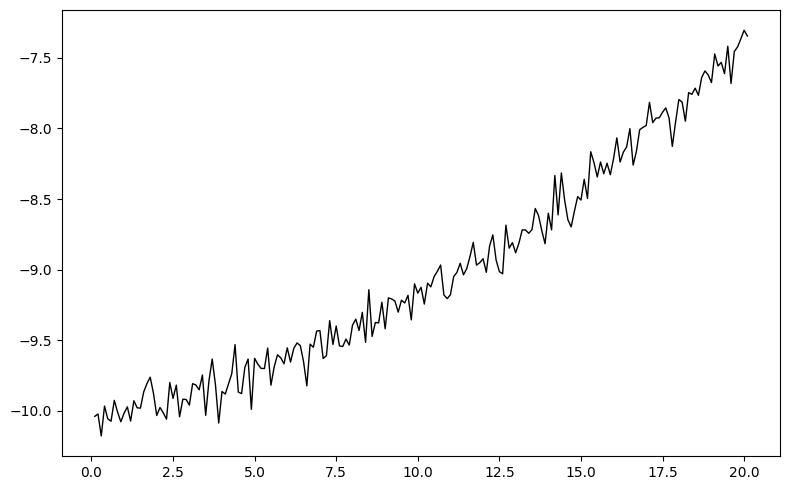

In [1]:
from jax import numpy as jnp
from matplotlib import pyplot as plt

from pyfilter.models.linear import GaussianSelectionTransform, IntegratorChainTransition
import jax

from dataclasses import dataclass 

@dataclass
class Simulation:
    """Simulation container."""
    n: int
    dt: float
    sigma: float

    @property
    def generating_transition(self) ->IntegratorChainTransition:
        return IntegratorChainTransition(n=3, p=3)

    @property
    def time_step(self) -> jnp.ndarray:
        return jnp.array(self.dt)

    def scan(self,x: jnp.ndarray,xs) -> tuple[jnp.ndarray,jnp.ndarray]:
        xnew = self.generating_transition.transform(x,self.time_step)
        return xnew,xnew
    
    def __call__(
            self,
            x0: jnp.ndarray,
            key: jnp.ndarray
    ) -> tuple[jnp.ndarray,jnp.ndarray,jnp.ndarray]:
        """Do the simulation."""
        dt = jnp.repeat(self.time_step,self.n + 1)
        time = jnp.cumsum(dt)
        _,x = jax.lax.scan(self.scan,x0,length = len(time))
        noise = jax.random.normal(key, shape=(self.n + 1, 9))*self.sigma

        return time, x, x + noise

#Initialize with some random values.
x0 = jnp.array([1, -10, 1, -0.15, 0.03, 1, 0.001, 0.01, -0.2])
simulation = Simulation(200,0.1,0.1)
key = jax.random.key(45)
time, truth, x = simulation(x0,key)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(time,x[:,1], lw=1.0, color="k")
fig.tight_layout()

## Numerical Stability

To demonstrate the superior numerical stability of the square root filter, we filter the simulated data using the square root filter. 

In [74]:
from pyfilter.types import GaussianRV
from pyfilter.types.covariance import DiagonalCovariance
import numpy as np
from pyfilter.filter.linear import SquareRootLinearGuassianKalman, LinearGaussianKalman, BaseLinearGaussianKalmanFilter
from matplotlib import pyplot as plt
from matplotlib.axes import Axes
from numpy.typing import NDArray
from typing import Any

#Scale the z dimension by this value.
z_scale = 1e20

init_std = np.ones((1, 9))*simulation.sigma
init_std[:, jnp.array([2,5,8])] *= z_scale
x_transform = x.at[...,jnp.array([2,5,8])].multiply(z_scale)

#Prior for the initial x.
xinit_prior = GaussianRV(jnp.array(x_transform[0:1, :]), DiagonalCovariance(jnp.array(init_std)))

# Sample from the initial prior
init_key = jax.random.split(key)[0]
x_init_mean = jax.random.multivariate_normal(init_key,xinit_prior.mean,xinit_prior.covariance.full())
x_init_cov = xinit_prior.covariance

# Setup measurements
N = len(x) - 1
measurements = GaussianRV(
    x_transform[1:, jnp.array([0, 1, 2])],                              # (N, 3)
    DiagonalCovariance(jnp.broadcast_to(init_std[:,:3], (N, 3))),
)
time_steps = jnp.diff(time) 

@dataclass
class FilterScan:

    filter: BaseLinearGaussianKalmanFilter

    def step(self,state, xs):
        measurement, dt = xs
        update = self.filter.step_update(state, measurement, dt)
        return update, update

    def __call__(
        self,
        init_state : GaussianRV,
        measurements : GaussianRV,
        time_steps: jnp.ndarray
    ) -> GaussianRV:
        _, estimate_sq = jax.lax.scan(self.step, init_state, (measurements, time_steps))
        return estimate_sq
    
def plot_estimate(axes: NDArray,estimate: GaussianRV,**kwargs: Any):
    for i, ax in enumerate(axes.flat):
        ax.plot(time, truth[:, i], lw=1.0, color="k", ls="-", label="Truth")
        ax.plot(
            time[1:], estimate.mean[:, i], **kwargs
        )

    return axes

def setup_axes(axes: NDArray):

    y_labels = [r"Position $(m/s)$", r"Velocity $(m/s^2)$", r"Acceleration $(m/s^3)$"]
    titles = ["X", "Y", "Z"]

    for ax, label in zip(axes[:, 0], y_labels):
        ax.set_ylabel(label, fontsize=12)

    for ax, label in zip(axes[0, :], titles):
        ax.set_title(label, fontsize=12)

    for ax in axes[-1, :]:
        ax.set_xlabel(r"Time $(s)$", fontsize=12)

    return axes



### Square Root Filter

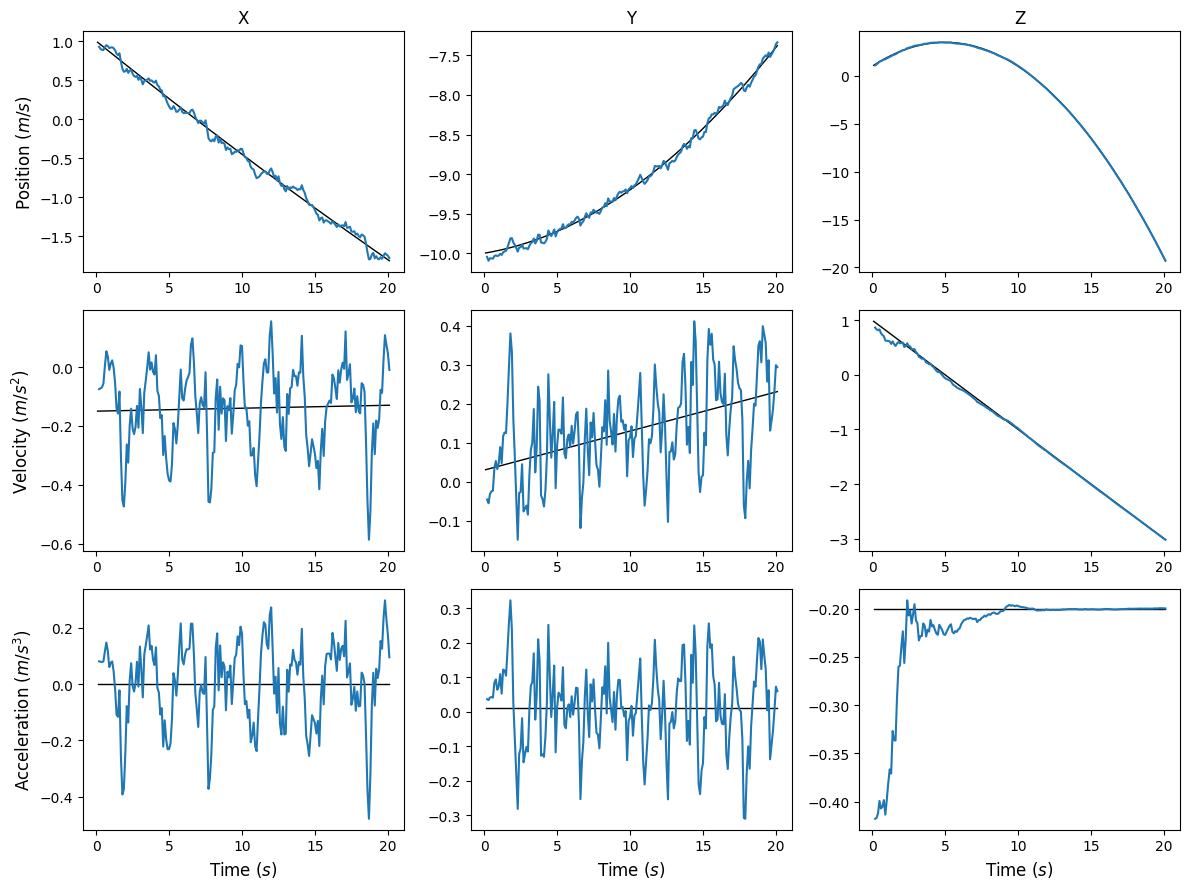

In [75]:

from pyfilter.types import GaussianRV
from pyfilter.types.covariance import (
    CholeskyFactorCovariance,
)
from pyfilter.types.process_noise import WeinerProcessNoise

#Create the square root filter.
square_root_filter = SquareRootLinearGuassianKalman(
    IntegratorChainTransition(n=3, p=3),
    WeinerProcessNoise(3, 3,simulation.sigma),
    GaussianSelectionTransform(slice(0, 3), 9),
)
state = GaussianRV(
    x_init_mean.squeeze(),CholeskyFactorCovariance(x_init_cov.cholesky_factor.squeeze())
)
fscan = FilterScan(square_root_filter)
estimate_sq = fscan(state,measurements,time_steps)
                 
estimate_sq = GaussianRV(
    estimate_sq.mean.at[...,jnp.array([2,5,8])].divide(z_scale),
    CholeskyFactorCovariance(
        estimate_sq.covariance.full().at[...,jnp.array([2,5,8]),:].divide(z_scale).at[...,:,jnp.array([2,5,8])].divide(z_scale)
    )
)

fig, axes = plt.subplots(figsize=(12, 9), nrows=3, ncols=3)
axes = setup_axes(axes)
plot_estimate(axes,estimate_sq)
fig.tight_layout()

### Normal Filter

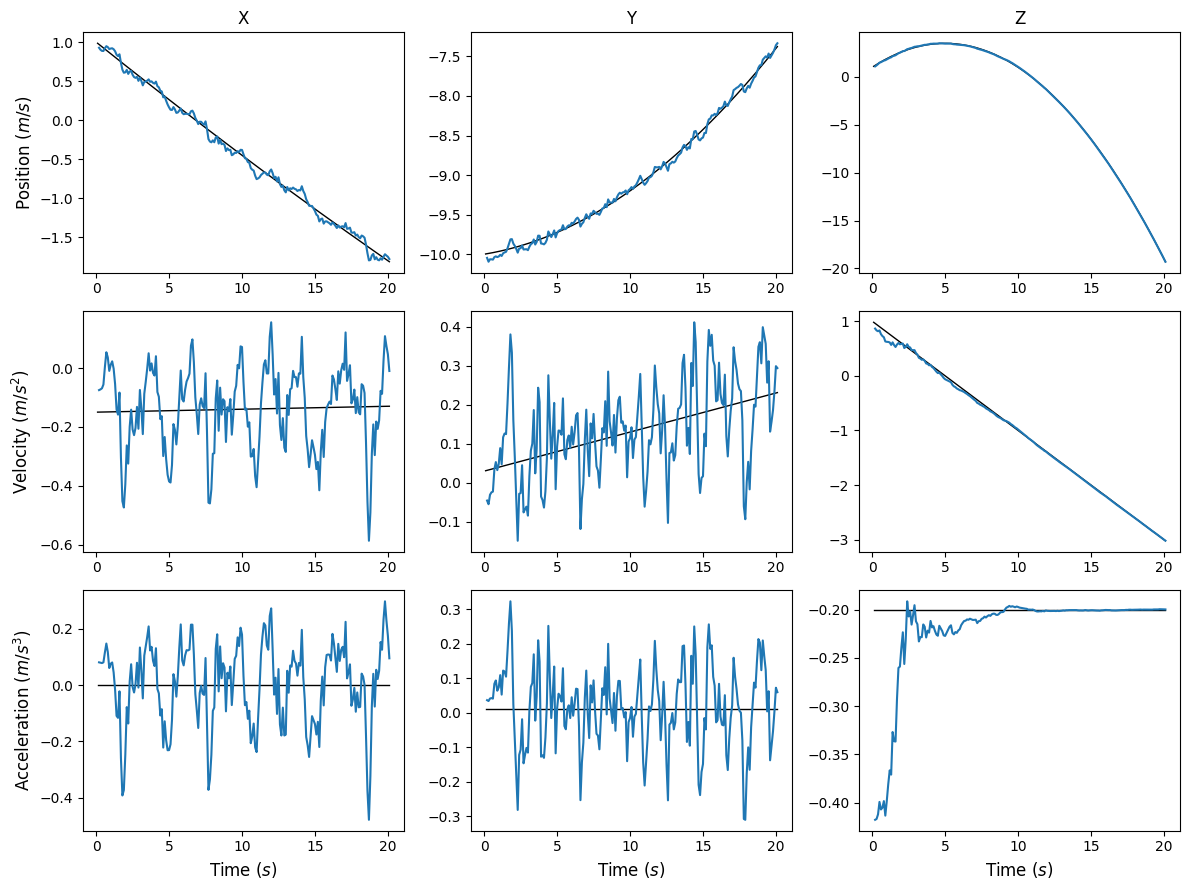

In [76]:
from pyfilter.filter.linear import LinearGaussianKalman
from pyfilter.types import GaussianRV
from pyfilter.types.process_noise import WeinerProcessNoise

#Create the filter.
linear_filter = LinearGaussianKalman(
    IntegratorChainTransition(n=3, p=3),
    WeinerProcessNoise(3, 3,simulation.sigma),
    GaussianSelectionTransform(slice(0, 3), 9),
)
state = GaussianRV(
    x_init_mean.squeeze(),x_init_cov.full().squeeze()
)
                 
fscan = FilterScan(linear_filter)
estimate_sq = fscan(state,measurements,time_steps)
                 
estimate_sq = GaussianRV(
    estimate_sq.mean.at[...,jnp.array([2,5,8])].divide(z_scale),
    estimate_sq.covariance.at[...,jnp.array([2,5,8]),:].divide(z_scale).at[...,:,jnp.array([2,5,8])].divide(z_scale)
)

fig, axes = plt.subplots(figsize=(12, 9), nrows=3, ncols=3)
axes = setup_axes(axes)
plot_estimate(axes,estimate_sq)
fig.tight_layout()